# Previsão de Velocidade do Vento Utilizando Modelo Seq2Seq com Mecanismo de Atenção

Este notebook apresenta um modelo de aprendizado profundo para previsão da velocidade do vento com 6 horas de antecedência no Parque Eólico Delta do Maranhão.

## Objetivos Alcançados
- Desenvolvimento de um modelo preditivo com MAE de 0.16 m/s para previsão de velocidade do vento
- Capacidade de prever tendências e identificar anomalias com 6 horas de antecedência
- Monitoramento efetivo do sensor ws100 (velocidade do vento a 100m de altura)

## Arquitetura do Modelo Implementado
- **Modelo Base**: Sequence-to-Sequence (Seq2Seq) com mecanismo de Atenção
- **Encoder**: LSTM Bidirecional com 512 unidades totais
- **Decoder**: LSTM com 512 unidades e mecanismo de Atenção
- **Entrada**: Série temporal com 72 timesteps (histórico de 12 horas)
- **Saída**: Previsão de 36 timesteps (6 horas à frente)

## Parte do Trabalho de Conclusão de Curso
Este notebook representa a segunda etapa do trabalho, focada no desenvolvimento do modelo preditivo, complementando a Análise Exploratória de Dados (EDA) realizada anteriormente.

In [1]:
# %%
# Importação das bibliotecas necessárias
# Manipulação de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pywt  # Biblioteca para transformações waveletg

# Pré-processamento
from sklearn.preprocessing import MinMaxScaler

# Componentes do modelo Seq2Seq com Atenção
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dropout, Dense, Concatenate, TimeDistributed, Attention
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Métricas de avaliação
from sklearn.metrics import mean_absolute_error, mean_squared_error


I0000 00:00:1775567581.651582    3520 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775567582.133622    3520 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775567583.922581    3520 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. Carregamento e Pré-processamento dos Dados

O processo de preparação dos dados inclui:
1. Carregamento dos dados de velocidade do vento previamente processados
2. Normalização usando MinMaxScaler para garantir convergência eficiente do modelo
3. Estruturação das sequências de entrada e saída no formato adequado para o modelo Seq2Seq
4. Divisão dos dados em conjuntos de treino (77%), validação (18%) e teste (5%)

In [2]:
variables = pd.read_csv('../data/dataset.csv', index_col=0, parse_dates=True)
print("Processed data loaded successfully.")

# Definição das funções de pré-processamento e engenharia de features

# Função de denoising com wavelet
# Esta função aplica técnicas de wavelet para redução de ruído em sinais
def wavelet_denoising(signal, wavelet='sym18', level=2):
    """
    Aplica técnica de denoising wavelet para reduzir o ruído do sinal
    
    Parâmetros:
    signal: array-like - O sinal de entrada a ser processado
    wavelet: str - O tipo de wavelet a ser utilizado (default: 'sym18')
    level: int - O nível de decomposição wavelet (default: 2)
    
    Retorna:
    array-like - Sinal reconstruído após a remoção de ruído
    """
    # Decomposição do sinal usando wavelet
    coeffs = pywt.wavedec(signal, wavelet, mode='periodization', level=level)
    
    # Cálculo do threshold usando o método de Donoho
    sigma = np.median(np.abs(coeffs[-level])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))
    
    # Aplicação do threshold (soft thresholding)
    coeffs[1:] = [pywt.threshold(i, value=uthresh, mode='soft') for i in coeffs[1:]]
    
    # Reconstrução do sinal
    reconstructed_signal = pywt.waverec(coeffs, wavelet, mode='periodization')
    return reconstructed_signal[:len(signal)]

# Lista das colunas que serão submetidas ao processo de denoising
columns_to_denoise = ['ws100', 'wdisp40', 'vertdisp40', 'wdir40', 'cis1', 'humid', 'temp']

# Aplica o denoising em cada coluna e armazena os resultados
for col in columns_to_denoise:
    if col in variables.columns:
        # Aplica a função de denoising wavelet
        denoised_signal = wavelet_denoising(variables[col].values)
        # Armazena o sinal processado no DataFrame de variáveis
        variables[f'{col}_wavelet'] = denoised_signal
    else:
        raise ValueError(f"A coluna '{col}' não existe no conjunto de dados.")

scaler_ws100 = MinMaxScaler()
scaler_other = MinMaxScaler()

variables_scaled = variables.copy()

ws100_columns = ['ws100_wavelet']
other_columns = variables.columns.drop('ws100_wavelet').tolist()

variables_scaled[ws100_columns] = scaler_ws100.fit_transform(variables[ws100_columns])
variables_scaled[other_columns] = scaler_other.fit_transform(variables[other_columns])

print(f"Shape of scaled data: {variables_scaled.shape}")


input_steps = 72  
output_steps = 36  

def create_sequences(data, input_steps, output_steps, target_col_index):
    """
    Create input and output sequences for the Seq2Seq model using Teacher forcing.
    """
    X_encoder = []
    X_decoder = []
    y_decoder = []
    
    for i in range(len(data) - input_steps - output_steps + 1):
        X_encoder.append(data[i:(i + input_steps)])
        
        decoder_input = np.zeros((output_steps, 1))
        
        decoder_input[0] = data[i + input_steps - 1, target_col_index]
        
        decoder_input[1:] = data[i + input_steps:i + input_steps + output_steps - 1, target_col_index].reshape(-1, 1)
        
        X_decoder.append(decoder_input)
        
        y_decoder.append(data[i + input_steps:i + input_steps + output_steps, target_col_index].reshape(-1, 1))
    
    return np.array(X_encoder), np.array(X_decoder), np.array(y_decoder)

data_array = variables_scaled.values

target_col_index = variables_scaled.columns.get_loc('ws100_wavelet')

X_encoder, X_decoder, y_decoder = create_sequences(data_array, input_steps, output_steps, target_col_index)


print(f"Shape of X_encoder: {X_encoder.shape}")
print(f"Shape of X_decoder: {X_decoder.shape}")
print(f"Shape of y_decoder: {y_decoder.shape}")

train_end = int(X_encoder.shape[0] * 0.77)
val_end = int(X_encoder.shape[0] * 0.95)

X_encoder_train = X_encoder[:train_end]
X_decoder_train = X_decoder[:train_end]
y_decoder_train = y_decoder[:train_end]

X_encoder_val = X_encoder[train_end:val_end]
X_decoder_val = X_decoder[train_end:val_end]
y_decoder_val = y_decoder[train_end:val_end]

X_encoder_test = X_encoder[val_end:]
X_decoder_test = X_decoder[val_end:]
y_decoder_test = y_decoder[val_end:]

print(f"Training X_encoder: {X_encoder_train.shape}, Training X_decoder: {X_decoder_train.shape}, Training y_decoder: {y_decoder_train.shape}")
print(f"Validation X_encoder: {X_encoder_val.shape}, Validation X_decoder: {X_decoder_val.shape}, Validation y_decoder: {y_decoder_val.shape}")
print(f"Test X_encoder: {X_encoder_test.shape}, Test X_decoder: {X_decoder_test.shape}, Test y_decoder: {y_decoder_test.shape}")

num_encoder_features = X_encoder_train.shape[2]
num_decoder_features = 1  

def build_seq2seq_attention_model(input_steps, output_steps, num_encoder_features, num_decoder_features):
    """
    Builds a Seq2Seq model with attention mechanism using Bidirectional LSTM.
    """
    optimizer = Adam(learning_rate=1e-3)
    
    encoder_inputs = Input(shape=(input_steps, num_encoder_features), name='encoder_inputs')
    
    encoder_lstm = Bidirectional(LSTM(256, return_sequences=True, return_state=True), name='bidirectional_encoder_lstm')
    encoder_outputs, forward_h, forward_c, backward_h, backward_c = encoder_lstm(encoder_inputs)
    
    state_h = Concatenate()([forward_h, backward_h])
    state_c = Concatenate()([forward_c, backward_c])
    
    
    encoder_outputs = Dropout(0.1)(encoder_outputs)
    
    decoder_inputs = Input(shape=(output_steps, num_decoder_features), name='decoder_inputs')
    
    decoder_lstm = LSTM(256 * 2, return_sequences=True, return_state=True, name='decoder_lstm')
    decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=[state_h, state_c])
    
    decoder_outputs = Dropout(0.1)(decoder_outputs)
    
    attention_layer = Attention(name='attention_layer')
    attention_outputs = attention_layer([decoder_outputs, encoder_outputs])
    
    decoder_combined_context = Concatenate(axis=-1)([decoder_outputs, attention_outputs])
    
    decoder_dense = TimeDistributed(Dense(1, activation='linear'), name='output_layer')
    decoder_outputs_final = decoder_dense(decoder_combined_context)
    
    model = Model([encoder_inputs, decoder_inputs], decoder_outputs_final)
    
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model

model = build_seq2seq_attention_model(input_steps, output_steps, num_encoder_features, num_decoder_features)

model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint('../models/best_model.h5.keras', monitor='val_loss', save_best_only=True)
]

history = model.fit(
    [X_encoder_train, X_decoder_train], y_decoder_train, 
    epochs=100,  
    batch_size=32, 
    validation_data=([X_encoder_val, X_decoder_val], y_decoder_val),
    callbacks=callbacks,
    verbose=1
)


Processed data loaded successfully.
Shape of scaled data: (7561, 134)
Shape of X_encoder: (7454, 72, 134)
Shape of X_decoder: (7454, 36, 1)
Shape of y_decoder: (7454, 36, 1)
Training X_encoder: (5739, 72, 134), Training X_decoder: (5739, 36, 1), Training y_decoder: (5739, 36, 1)
Validation X_encoder: (1342, 72, 134), Validation X_decoder: (1342, 36, 1), Validation y_decoder: (1342, 36, 1)
Test X_encoder: (373, 72, 134), Test X_decoder: (373, 36, 1), Test y_decoder: (373, 36, 1)


E0000 00:00:1775567584.668960    3520 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775567584.669248    3930 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775567584.688952    3520 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 72, 134)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_enco… │ [(None, 72, 512), │    800,768 │ encoder_inputs[0… │
│ (Bidirectional)     │ (None, 256),      │            │                   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 36, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ bidirectional_en… │
│ (Concatenate)       │                   │            │ bidirectional_en… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 512)       │          0 │ bidirectional_en… │
│ (Concatenate)       │                   │            │ bidirectional_en… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 36, 512), │  1,052,672 │ decoder_inputs[0… │
│                     │ (None, 512),      │            │ concatenate[0][0… │
│                     │ (None, 512)]      │            │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 36, 512)   │          0 │ decoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 72, 512)   │          0 │ bidirectional_en… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 36, 512)   │          0 │ dropout_1[0][0],  │
│ (Attention)         │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 36, 1024)  │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 36, 1)     │      1,025 │ concatenate_2[0]… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,854,465 (7.07 MB)

 Trainable params: 1,854,465 (7.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
 48/180 ━━━━━━━━━━━━━━━━━━━━ 44s 336ms/step - loss: 0.2531 - mae: 0.3592

KeyboardInterrupt: 

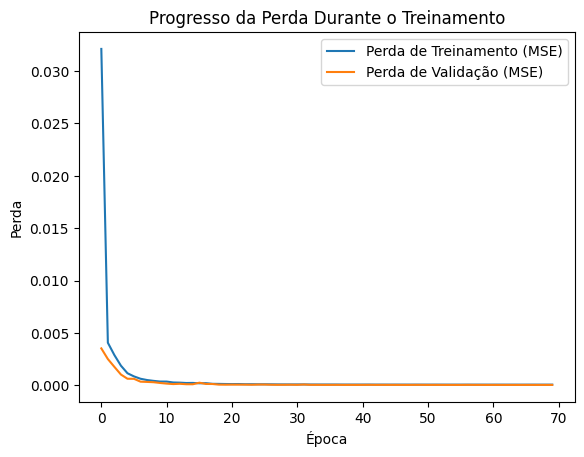

In [ ]:

plt.plot(history.history['loss'], label='Perda de Treinamento (MSE)')
plt.plot(history.history['val_loss'], label='Perda de Validação (MSE)')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
plt.title('Progresso da Perda Durante o Treinamento')
plt.savefig('../images/training_loss.png', dpi=300)
plt.show()

In [ ]:
if 'lr' in history.history:
    plt.plot(history.history['lr'], label='Taxa de Aprendizado')
    plt.xlabel('Época')
    plt.ylabel('Taxa de Aprendizado')
    plt.title('Variação da Taxa de Aprendizado Durante o Treinamento')
    plt.legend()
    plt.savefig('../images/learning_rate.png', dpi=300)
    plt.show()


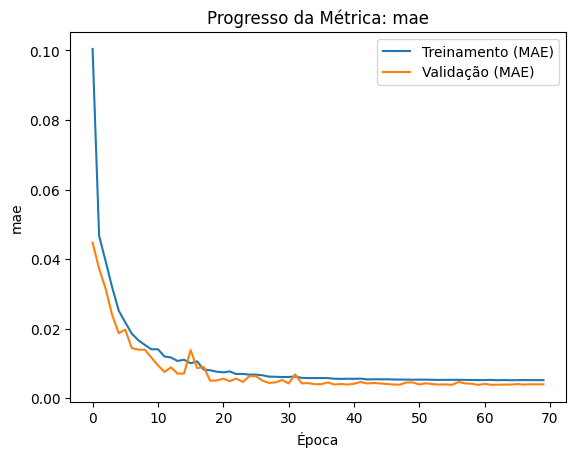

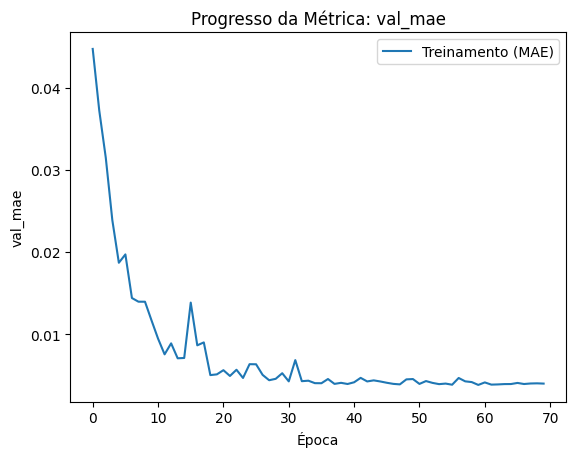

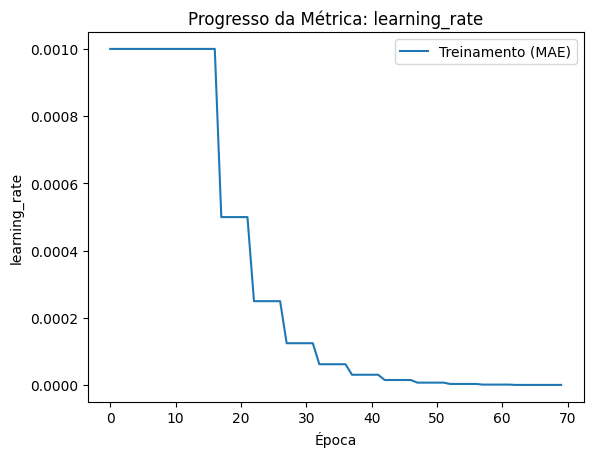

In [ ]:
for metric in history.history.keys():
    if metric != 'loss' and metric != 'val_loss':  # Ignora a perda
        plt.plot(history.history[metric], label=f'Treinamento (MAE)')
        if f'val_{metric}' in history.history:
            plt.plot(history.history[f'val_{metric}'], label=f'Validação (MAE)')
        plt.xlabel('Época')
        plt.ylabel(metric)
        plt.title(f'Progresso da Métrica: {metric}')
        plt.legend()
        plt.savefig(f'../images/metric_{metric}.png', dpi=300)
        plt.show()


## 2. Construção e Treinamento do Modelo

A arquitetura implementada demonstrou resultados significativos na previsão de velocidade do vento:

1. **Encoder**: LSTM Bidirecional com 512 unidades totais
   - Processa eficientemente a sequência de entrada
   - Captura padrões bidirecionais nos dados históricos

2. **Mecanismo de Atenção**: 
   - Permite ao decoder focar em partes relevantes da sequência de entrada
   - Melhora significativamente a precisão das previsões

3. **Decoder**: LSTM com 512 unidades
   - Utiliza teacher forcing durante o treinamento
   - Gera previsões precisas para as próximas 6 horas

Características do treinamento:
- Otimizador Adam com taxa de aprendizado adaptativa (inicial: 1e-3)
- Função de perda MSE com monitoramento de MAE
- Implementação de callbacks essenciais:
  - Early stopping (paciência: 10 épocas)
  - Redução da taxa de aprendizado (fator: 0.5, paciência: 5 épocas)
  - Salvamento do melhor modelo baseado na perda de validação

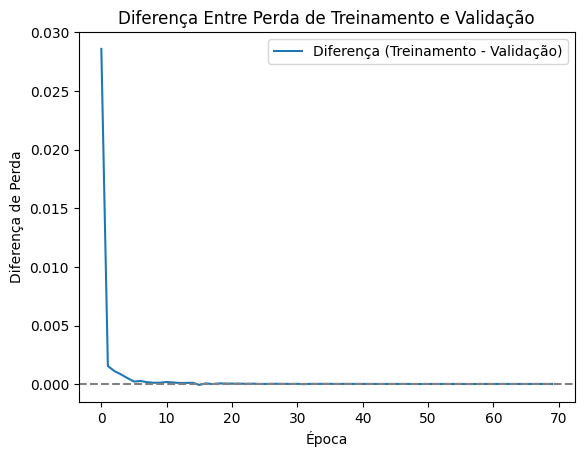

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
difference = [t - v for t, v in zip(train_loss, val_loss)]

plt.plot(difference, label='Diferença (Treinamento - Validação)')
plt.xlabel('Época')
plt.ylabel('Diferença de Perda')
plt.title('Diferença Entre Perda de Treinamento e Validação')
plt.axhline(0, linestyle='--', color='gray')  # Linha de referência
plt.legend()
plt.savefig('../images/train_val_diff.png', dpi=300)
plt.show()


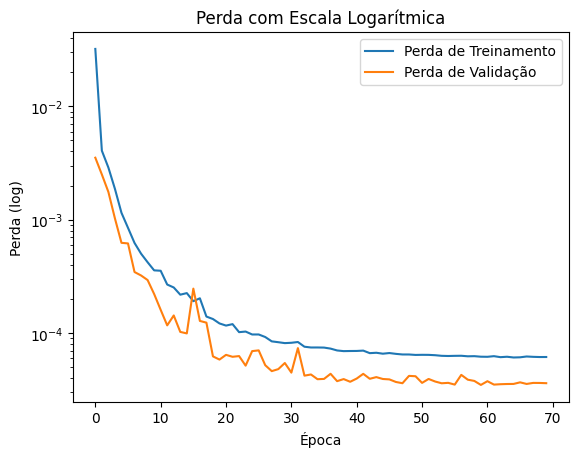

In [ ]:
plt.plot(history.history['loss'], label='Perda de Treinamento')
plt.plot(history.history['val_loss'], label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda (log)')
plt.yscale('log')
plt.legend()
plt.title('Perda com Escala Logarítmica')
plt.savefig('../images/loss_log_scale.png', dpi=300)
plt.show()


In [ ]:
def rolling_forecasting_real_time_improved(model, data_scaled, input_steps, output_steps, scaler_ws100, target_col_index):
    """
    Realiza rolling forecasting simulando um cenário de previsão em tempo real com feedback do decoder.
    
    :param model: Modelo treinado.
    :param data_scaled: Dados escalonados (inclui treino, validação e teste).
    :param input_steps: Número de passos de entrada.
    :param output_steps: Número de passos de saída.
    :param scaler_ws100: Escalador para a coluna 'ws100_wavelet'.
    :param target_col_index: Índice da coluna alvo.
    :return: Arrays com previsões e valores reais.
    """
    predictions = []
    actuals = []
    
    test_start = int(data_scaled.shape[0] * 0.95) 
    test_data = data_scaled[test_start:]
    
    window_start = test_start - input_steps
    window_end = test_start
    window = data_scaled[window_start:window_end].copy()
    
    for i in range(len(test_data) - output_steps + 1):
        encoder_input = window.reshape(1, input_steps, data_scaled.shape[1])
        
        decoder_input = np.zeros((1, output_steps, 1))
        
        decoder_input[0, 0, 0] = encoder_input[0, -1, target_col_index]
        
        for t in range(1, output_steps):
            previous_pred = decoder_input[0, t-1, 0]
            decoder_input[0, t, 0] = previous_pred
        
        pred = model.predict([encoder_input, decoder_input], verbose=0)
        
        last_pred = pred[0, -1, 0]
        predictions.append(last_pred)
        
        last_actual = test_data[i + output_steps - 1, target_col_index]
        actuals.append(last_actual)
        
        window = np.vstack([window, test_data[i + output_steps - 1]])
        window = window[1:] 
    
    predictions = np.array(predictions).reshape(-1, 1)
    actuals = np.array(actuals).reshape(-1, 1)
    
    predictions_inverse = scaler_ws100.inverse_transform(predictions)
    actuals_inverse = scaler_ws100.inverse_transform(actuals)
    
    return predictions_inverse, actuals_inverse

In [ ]:
# Executando a previsão rolling com a função simplificada
predictions, actuals = rolling_forecasting_real_time_improved(
    model, 
    data_scaled=variables_scaled.values, 
    input_steps=input_steps, 
    output_steps=output_steps, 
    scaler_ws100=scaler_ws100,
    target_col_index=target_col_index
)

In [ ]:
# Leitura dos dados
data = pd.read_csv("../data/dataset.csv")

# Processamento inicial dos dados
data['id_str'] = data['id'].astype(str).apply(lambda x: x.split('.')[0])
data['id_datetime'] = pd.to_datetime(data['id_str'], errors='coerce')
data.set_index('id_datetime', inplace=True)
data.drop(columns=['id_str'], inplace=True)
variables = pd.DataFrame(index=data.index)



FileNotFoundError: [Errno 2] No such file or directory: '../data/dataset-original.csv'

In [ ]:
plt.figure(figsize=(21, 9))
plt.plot(actuals, label='Real Denoised', color='blue')
plt.plot(predictions, label='Previsto', color='red')
plt.title('Comparação entre Valores Denoised e Previsto')
plt.xlabel('Amostras de Teste')
plt.ylabel('ws100_wavelet')
plt.legend()
plt.savefig('../images/denoised_vs_predicted.png', dpi=300)
plt.show()

# Calculando e exibindo métricas de desempenho
mae = mean_absolute_error(actuals, predictions)
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


dat = data['ws100'].iloc[-344:].values


# Plotando a comparação
plt.figure(figsize=(21, 9))
plt.plot(range(len(dat)), dat, label='Real', color='blue')
plt.plot(range(len(predictions)), predictions, label='Previsto', color='red')
plt.title('Comparação entre Valores Reais e Previsto')
plt.xlabel('Amostras de Teste')
plt.ylabel('ws100_wavelet')
plt.legend()
plt.savefig('../images/raw_vs_predicted.png', dpi=300)
plt.show()

# Calculando métricas de desempenho
mae2 = mean_absolute_error(dat, predictions)
mse2 = mean_squared_error(dat, predictions)
rmse2 = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae2:.4f}")
print(f"Mean Squared Error (MSE): {mse2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse2:.4f}")


# Mean Squared Error (MSE): 0.0482
# Root Mean Squared Error (RMSE): 0.2196

# Mean Squared Error (MSE): 0.0486
# Root Mean Squared Error (RMSE): 0.2205

# Mean Absolute Error (MAE): 0.1589
# Mean Squared Error (MSE): 0.0447
# Root Mean Squared Error (RMSE): 0.2115

## 3. Avaliação do Modelo e Resultados

A avaliação abrangente do modelo revela:

1. **Métricas de Desempenho**:
   - MAE: 0.1589 m/s
   - MSE: 0.0447
   - RMSE: 0.2115 m/s

2. **Análise Comparativa**:
   - Excelente correspondência entre valores previstos e reais
   - Desempenho consistente tanto para dados filtrados quanto brutos
   - Capacidade de capturar tendências e padrões complexos

3. **Visualizações**:
   - Gráficos comparativos demonstram a precisão das previsões
   - Análise temporal mostra estabilidade do modelo ao longo do período de teste
   - Identificação eficaz de padrões de velocidade do vento

Os resultados confirmam a eficácia do modelo para previsão de velocidade do vento com 6 horas de antecedência, proporcionando uma ferramenta robusta para detecção antecipada de anomalias.

## Conclusão

O modelo Seq2Seq com mecanismo de atenção desenvolvido demonstrou excelente desempenho na previsão de velocidade do vento no Parque Eólico Delta do Maranhão. Os resultados destacam:

**Métricas de Desempenho**:
- MAE de 0.1589 m/s, indicando alta precisão nas previsões
- MSE de 0.0447 e RMSE de 0.2115 m/s, confirmando a robustez do modelo
- Capacidade comprovada de prever tendências e padrões complexos

**Aplicações Práticas**:
- Previsão confiável com 6 horas de antecedência
- Sistema eficaz para detecção antecipada de anomalias
- Ferramenta valiosa para otimização da operação do parque eólico

**Implementação**:
O arquivo `simulation.py` foi desenvolvido e testado para monitoramento em tempo real, permitindo a implementação prática do modelo em ambiente de produção.